# Cobertura espacial de la flota artesanal — VMS 2023

Notebook complementario a [01_xolot_trajectory.ipynb](01_xolot_trajectory.ipynb): en vez de seguir una sola embarcación, agrega **todos los pings VMS** de la flota artesanal sobre la ventana de **Caldera / Bahía Inglesa** — la misma ventana de foco que comparten las secciones 2 y 4 del notebook de XOLOT. Sirve para ver los caladeros recurrentes a nivel de flota y contextualizar la trayectoria de XOLOT dentro del patrón general.

Fuente: [../data/locations/locations_flota_artesanal_2023.csv](../data/locations/locations_flota_artesanal_2023.csv) — pings 2023 consolidados por [consolidate_locations.py](../processing/locations/consolidate_locations.py).

## 0. Setup

Mismo stack que [01_xolot_trajectory.ipynb](01_xolot_trajectory.ipynb): `pandas`, `numpy` y `matplotlib` ya vienen en la imagen Docker; `cartopy` se instala una sola vez. La función que calcula la línea de 5 mn (sección 2) es idéntica a la del notebook de XOLOT — se replica aquí para mantener el notebook autocontenido.

In [1]:
%pip install cartopy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except ImportError:
    HAS_CARTOPY = False
    print("Aviso: cartopy no disponible — el mapa se dibujará sin costa.")

plt.rcParams["figure.dpi"] = 110

## 1. Carga

Cargamos el CSV consolidado completo — sin filtrar por nombre, a diferencia de [01_xolot_trajectory.ipynb](01_xolot_trajectory.ipynb). Mismo contrato `dtype=str` que [`consolidate_locations.py`](../processing/locations/consolidate_locations.py) para preservar la precisión decimal de lat/lon y el formato de fecha/velocidad antes de convertir a tipos numéricos.

In [3]:
DATA_PATH = "data/locations/locations_flota_artesanal_2023.csv"

# Bbox completo de Atacama — misma definición que la grilla unificada en
# processing/utils/cmems_common.py (LAT_MIN/LAT_MAX/LON_MIN/LON_MAX). Se conserva
# como referencia regional; el análisis se concentra en la ventana de foco.
LAT_MIN, LAT_MAX = -29.0, -25.0
LON_MIN, LON_MAX = -72.0, -70.0

# Ventana de foco — ≈ Caldera / Bahía Inglesa, idéntica a la que comparten las
# secciones 2 y 4 de 01_xolot_trajectory.ipynb. Es donde se concentra la operación
# real de la flota artesanal en 2023; todo lo de aquí en adelante se filtra a ella.
FOCUS_LAT_MIN, FOCUS_LAT_MAX = -27.55, -26.55
FOCUS_LON_MIN, FOCUS_LON_MAX = -71.4, -70.8

df_raw = pd.read_csv(DATA_PATH, sep=";", dtype=str, encoding="utf-8")
print(f"Filas totales en el CSV consolidado: {len(df_raw):,}")
print(f"Columnas: {list(df_raw.columns)}")

Filas totales en el CSV consolidado: 4,865,298
Columnas: ['Name', 'Radio Call Sign (RC)', 'Location date', 'Latitude', 'Longitude', 'Heading', 'Speed (kt)']


In [4]:
df_raw["Latitude"]  = pd.to_numeric(df_raw["Latitude"],  errors="coerce")
df_raw["Longitude"] = pd.to_numeric(df_raw["Longitude"], errors="coerce")
df_raw["Location date"] = pd.to_datetime(
    df_raw["Location date"], format="%d/%m/%Y %H:%M:%S", errors="coerce"
)
# A diferencia de XOLOT, en la flota completa hay pings con 'Speed (kt)' = '-'
# (placeholder de Sernapesca para velocidad faltante). `to_numeric` con
# errors='coerce' los convierte a NaN sin romper el cast.
df_raw["Speed (kt)"] = pd.to_numeric(
    df_raw["Speed (kt)"].str.removesuffix(" kt"), errors="coerce"
)

df_clean = df_raw.dropna(subset=["Latitude", "Longitude", "Location date"]).reset_index(drop=True)
del df_raw

# Filtrado a la ventana de foco. El CSV consolidado trae bastante ruido (pings con
# lat/lon imposibles o de embarcaciones operando muy lejos de Atacama); este
# recorte deja sólo lo que cae en Caldera / Bahía Inglesa.
in_focus = (
    df_clean["Latitude"].between(FOCUS_LAT_MIN, FOCUS_LAT_MAX)
    & df_clean["Longitude"].between(FOCUS_LON_MIN, FOCUS_LON_MAX)
)
df = df_clean[in_focus].reset_index(drop=True)
del df_clean

print(f"Pings en ventana de foco: {len(df):,}")
print(f"Embarcaciones únicas:     {df['Name'].nunique():,}")
print(f"Pings sin velocidad:      {df['Speed (kt)'].isna().sum():,}")
print(f"Rango temporal:           {df['Location date'].min()}  →  {df['Location date'].max()}")
print(
    f"Bbox observado:           lat [{df['Latitude'].min():.3f}, {df['Latitude'].max():.3f}], "
    f"lon [{df['Longitude'].min():.3f}, {df['Longitude'].max():.3f}]"
)

Pings en ventana de foco: 58,960
Embarcaciones únicas:     81
Pings sin velocidad:      0
Rango temporal:           2023-01-17 01:38:03  →  2023-10-03 20:06:01
Bbox observado:           lat [-27.550, -26.550], lon [-71.400, -70.800]


## 2. Línea de 5 millas náuticas

Misma construcción que [01_xolot_trajectory.ipynb](01_xolot_trajectory.ipynb) — se buferan los polígonos de tierra de Natural Earth en UTM 19S por 9 260 m (5 mn) y se descarta el contorno coincidente con la costa. Aquí se aplica directamente a la ventana de foco (Caldera / Bahía Inglesa) para que coincida con la extensión de los mapas.

In [5]:
def _compute_offshore_5nm(lon_min, lon_max, lat_min, lat_max):
    if not HAS_CARTOPY:
        return []

    import pyproj
    from shapely.geometry import LineString, MultiLineString, box
    from shapely.ops import transform as shp_transform, unary_union

    work_box = box(lon_min - 1.0, lat_min - 1.0, lon_max + 1.0, lat_max + 1.0)
    land = cfeature.NaturalEarthFeature("physical", "land", "10m")
    pieces = [g.intersection(work_box) for g in land.geometries() if g.intersects(work_box)]
    pieces = [g for g in pieces if not g.is_empty]
    if not pieces:
        return []
    land_geo = unary_union(pieces)

    to_utm = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:32719", always_xy=True).transform
    to_geo = pyproj.Transformer.from_crs("EPSG:32719", "EPSG:4326", always_xy=True).transform

    land_utm = shp_transform(to_utm, land_geo)
    buffer_utm = land_utm.buffer(5 * 1852)  # 5 mn = 9 260 m

    offshore_utm = buffer_utm.boundary.difference(land_utm.boundary.buffer(1.0))
    offshore_geo = shp_transform(to_geo, offshore_utm)
    offshore_geo = offshore_geo.intersection(box(lon_min, lat_min, lon_max, lat_max))
    if offshore_geo.is_empty:
        return []

    if isinstance(offshore_geo, LineString):
        segs = [offshore_geo]
    elif isinstance(offshore_geo, MultiLineString):
        segs = list(offshore_geo.geoms)
    else:
        segs = [g for g in getattr(offshore_geo, "geoms", []) if isinstance(g, LineString)]

    return [(list(s.xy[0]), list(s.xy[1])) for s in segs]


OFFSHORE_5NM = _compute_offshore_5nm(
    FOCUS_LON_MIN, FOCUS_LON_MAX, FOCUS_LAT_MIN, FOCUS_LAT_MAX
)


def plot_offshore_5nm(ax, transform=None, label=True):
    """Dibuja la línea de 5 mn como referencia tenue sobre `ax`."""
    base = dict(color="#b22222", linewidth=1.1, linestyle="--", alpha=0.5)
    if transform is not None:
        base["transform"] = transform
    for i, (xs, ys) in enumerate(OFFSHORE_5NM):
        kwargs = dict(base)
        if label and i == 0:
            kwargs["label"] = "5 mn de la costa"
        ax.plot(xs, ys, **kwargs)


print(f"Segmentos en la línea de 5 mn: {len(OFFSHORE_5NM)}")

Segmentos en la línea de 5 mn: 1


## 3. Idoneidad de hábitat para jurel (*Trachurus murphyi*)

Capa ambiental que se superpondrá como heatmap bajo los paneles semanales. La idea es decir, para cada celda de la grilla unificada SST/CHL (1/24°, definida en [processing/utils/cmems_common.py](../processing/utils/cmems_common.py)), qué tan "bueno" es ese punto para jurel en una semana dada, en una escala 0–1.

El score combina dos preferencias derivadas de literatura sobre *Trachurus murphyi* en el sistema Humboldt:

- **SST (temperatura superficial)**: jurel adulto se concentra en aguas de 14–19 °C; la idoneidad cae a 0 fuera del rango 10–23 °C. Función trapezoidal entre esos extremos.
- **CHL (clorofila-a)**: proxy de productividad zooplanctónica. La idoneidad sube en forma logística desde aguas pobres (< 0.3 mg/m³) hasta saturar cerca de 2 mg/m³ — no se penalizan blooms muy intensos por simplicidad.

El score combinado es `sst_suit × chl_suit`. Los umbrales son **literatura, no datos** — viven como constantes nombradas al inicio del cell de código y se pueden recalibrar sin tocar el resto del notebook. Si en algún panel el verde se ve homogéneo (ej. toda la ventana cae dentro del plateau de SST), el factor discriminante en la práctica es CHL.

In [ ]:
import xarray as xr

# ---------------------------------------------------------------------------
# Umbrales de literatura para Trachurus murphyi en el sistema Humboldt.
# Ajustar acá si se quieren recalibrar las preferencias sin tocar el resto del
# notebook.
# ---------------------------------------------------------------------------
SST_PLATEAU    = (14.0, 19.0)   # °C, rango óptimo de adultos (idoneidad = 1)
SST_TOLERANCE  = (10.0, 23.0)   # °C, fuera de aquí la idoneidad = 0
CHL_HALF_SAT   = 0.5            # mg/m³, donde la idoneidad por CHL = 0.5
CHL_SATURATION = 2.0            # mg/m³, donde la idoneidad por CHL ≈ 0.95

SST_PATH = "data/copernicus/sst_atacama_2023.nc"
CHL_PATH = "data/copernicus/chl_atacama_2023.nc"


def sst_suitability(sst):
    """Trapezoidal: 0 fuera de SST_TOLERANCE, plateau en SST_PLATEAU, rampas lineales."""
    tmin, tmax = SST_TOLERANCE
    pmin, pmax = SST_PLATEAU
    sst = np.asarray(sst, dtype=float)
    rise = (sst - tmin) / (pmin - tmin)
    fall = (tmax - sst) / (tmax - pmax)
    score = np.minimum(np.minimum(rise, fall), 1.0)
    return np.clip(score, 0.0, 1.0)


def chl_suitability(chl):
    """Logística sobre log10(chl): half-sat en CHL_HALF_SAT, satura cerca de CHL_SATURATION."""
    chl = np.asarray(chl, dtype=float)
    # k se elige para que CHL_SATURATION dé ≈ 0.95.
    k = np.log(0.95 / 0.05) / (np.log10(CHL_SATURATION) - np.log10(CHL_HALF_SAT))
    safe = np.where(chl > 0, chl, np.nan)
    return 1.0 / (1.0 + np.exp(-k * (np.log10(safe) - np.log10(CHL_HALF_SAT))))


def combined_suitability(sst, chl):
    """Producto de las dos preferencias; NaN si cualquiera de los dos es NaN."""
    return sst_suitability(sst) * chl_suitability(chl)


# Verificación rápida de las curvas sobre puntos representativos.
sst_check = np.array([8.0, 12.0, 14.0, 16.5, 19.0, 21.0, 24.0])
chl_check = np.array([0.1, 0.3, 0.5, 1.0, 2.0, 5.0])
print("sst_suitability:", np.round(sst_suitability(sst_check), 2))
print("chl_suitability:", np.round(chl_suitability(chl_check), 2))

# ---------------------------------------------------------------------------
# Carga de SST y CHL en xarray. Recortamos a la ventana de foco para que las
# medias semanales sean baratas (la grilla nativa ya está en 1/24°, así que
# `sel` con `slice` deja celdas exactas — no hay interpolación).
# ---------------------------------------------------------------------------
sst_ds = xr.open_dataset(SST_PATH).sel(
    latitude=slice(FOCUS_LAT_MIN, FOCUS_LAT_MAX),
    longitude=slice(FOCUS_LON_MIN, FOCUS_LON_MAX),
)
chl_ds = xr.open_dataset(CHL_PATH).sel(
    latitude=slice(FOCUS_LAT_MIN, FOCUS_LAT_MAX),
    longitude=slice(FOCUS_LON_MIN, FOCUS_LON_MAX),
)
sst_da = sst_ds["analysed_sst"]
chl_da = chl_ds["CHL"]

print(
    f"\nSST: {sst_da.shape} {dict(sst_da.sizes)}  "
    f"tiempo {str(sst_da['time'].min().values)[:10]} → {str(sst_da['time'].max().values)[:10]}"
)
print(
    f"CHL: {chl_da.shape} {dict(chl_da.sizes)}  "
    f"tiempo {str(chl_da['time'].min().values)[:10]} → {str(chl_da['time'].max().values)[:10]}"
)


def weekly_suitability(start, end):
    """Promedia SST y CHL diarios en el rango [start, end) y devuelve el score 2D."""
    sst_mean = sst_da.sel(time=slice(start, end - pd.Timedelta(seconds=1))).mean(
        dim="time", skipna=True
    )
    chl_mean = chl_da.sel(time=slice(start, end - pd.Timedelta(seconds=1))).mean(
        dim="time", skipna=True
    )
    score = xr.apply_ufunc(combined_suitability, sst_mean, chl_mean)
    score.name = "habitat_suitability"
    return score

sst_suitability: [0.  0.5 1.  1.  1.  0.5 0. ]
chl_suitability: [0.03 0.25 0.5  0.81 0.95 0.99]


KeyError: "No variable named 'chl_mg_m3'. Variables on the dataset include ['CHL', 'time', 'latitude', 'longitude']"

## 4. Mapa de trayectorias de la flota

Mismo estilo que [01_xolot_trajectory.ipynb](01_xolot_trajectory.ipynb): cada ping VMS es un punto sobre la ventana de Caldera / Bahía Inglesa, con el color codificando velocidad instantánea — tonos oscuros (≲ 2 kt) suelen marcar pesca activa o calado, claros (≳ 5 kt) navegación. La diferencia es que aquí se grafica la flota completa, no una sola embarcación.

Los puntos se dibujan pequeños (`s=8`) y transparentes (`alpha=0.08`) para que la densidad emerja del solapamiento. Los pings con velocidad faltante (`-` en el CSV) quedan fuera de la figura porque no tienen color asignado — el conteo lo imprime la sección 1.

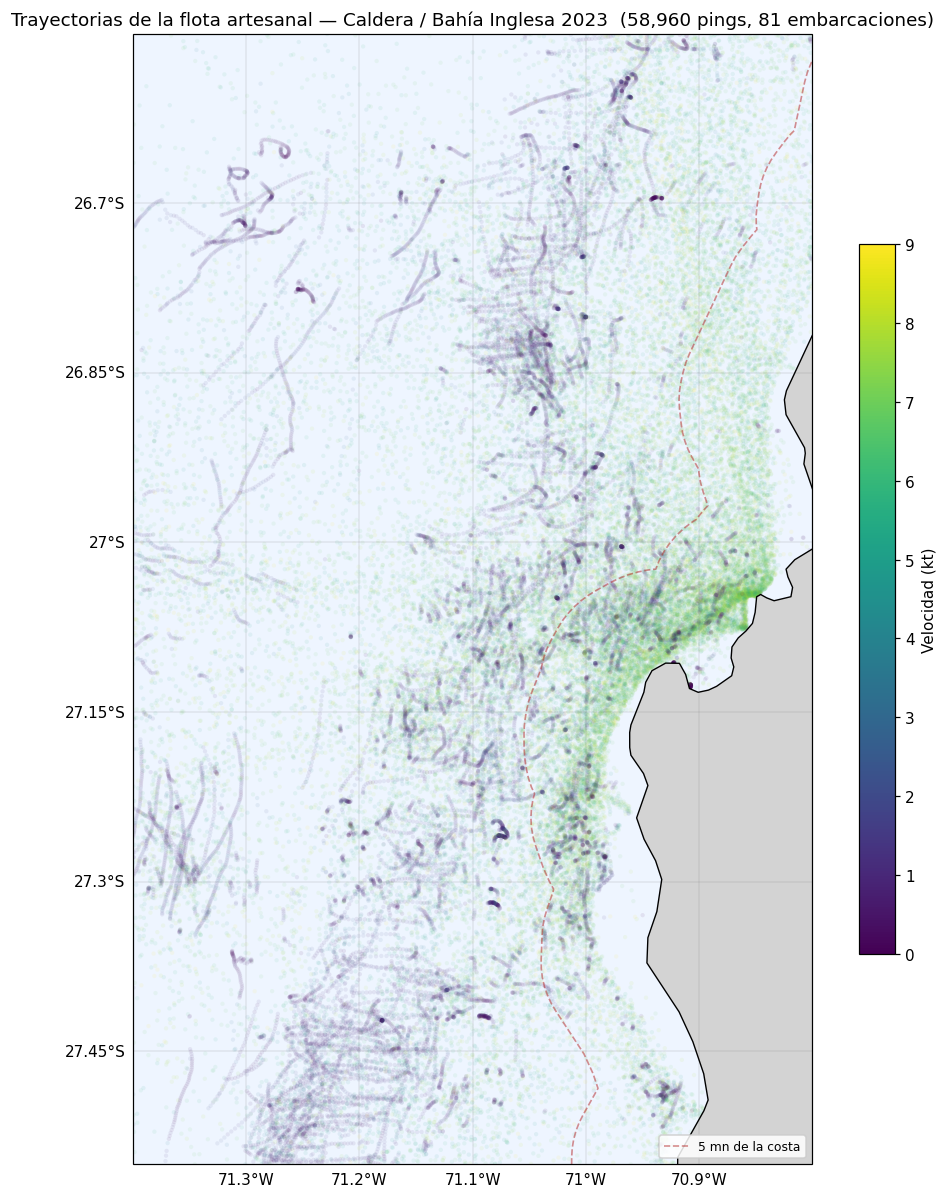

In [ ]:
# Misma escala de velocidad que en 01_xolot_trajectory.ipynb (percentil 98) — calculada
# sobre la flota dentro de la ventana de foco; se reusa en los paneles mensuales.
df_v = df.dropna(subset=["Speed (kt)"])
SPEED_VMAX = float(np.quantile(df_v["Speed (kt)"], 0.98))

fig = plt.figure(figsize=(8, 11))

if HAS_CARTOPY:
    ax_map = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax_map.set_extent(
        [FOCUS_LON_MIN, FOCUS_LON_MAX, FOCUS_LAT_MIN, FOCUS_LAT_MAX],
        crs=ccrs.PlateCarree(),
    )
    ax_map.add_feature(cfeature.OCEAN,     facecolor="#eef5ff")
    ax_map.add_feature(cfeature.LAND,      facecolor="lightgray", zorder=2)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.9, zorder=3)
    gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    transform = ccrs.PlateCarree()
else:
    ax_map = fig.add_subplot(1, 1, 1)
    ax_map.set_xlim(FOCUS_LON_MIN, FOCUS_LON_MAX)
    ax_map.set_ylim(FOCUS_LAT_MIN, FOCUS_LAT_MAX)
    ax_map.set_aspect("equal")
    ax_map.set_xlabel("Longitud")
    ax_map.set_ylabel("Latitud")
    ax_map.grid(True, linewidth=0.3, alpha=0.5)
    transform = None

scatter_kwargs = dict(
    c=df_v["Speed (kt)"], cmap="viridis", s=8, alpha=0.08,
    vmin=0, vmax=SPEED_VMAX,
    edgecolor="none",
    rasterized=True,
)
if transform is not None:
    scatter_kwargs["transform"] = transform

sc = ax_map.scatter(df_v["Longitude"], df_v["Latitude"], **scatter_kwargs)
plot_offshore_5nm(ax_map, transform=transform)
ax_map.legend(loc="lower right", fontsize=8, framealpha=0.85)

cbar = fig.colorbar(sc, ax=ax_map, fraction=0.045, pad=0.06)
cbar.set_label("Velocidad (kt)")
cbar.solids.set_alpha(1.0)  # la barra de color debe verse opaca aunque los puntos sean transparentes
ax_map.set_title(
    f"Trayectorias de la flota artesanal — Caldera / Bahía Inglesa 2023  "
    f"({len(df_v):,} pings, {df_v['Name'].nunique()} embarcaciones)"
)

plt.tight_layout()
plt.show()

## 5. Ranking de embarcaciones por actividad

Top 20 embarcaciones por número de pings VMS **dentro de la ventana de foco** (Caldera / Bahía Inglesa). Es un proxy razonable de tiempo en el mar para esa zona — pero **no** de captura: un bote puede pasar muchas horas calado (pings densos, velocidad ≈ 0) sin que eso se traduzca linealmente en desembarques.

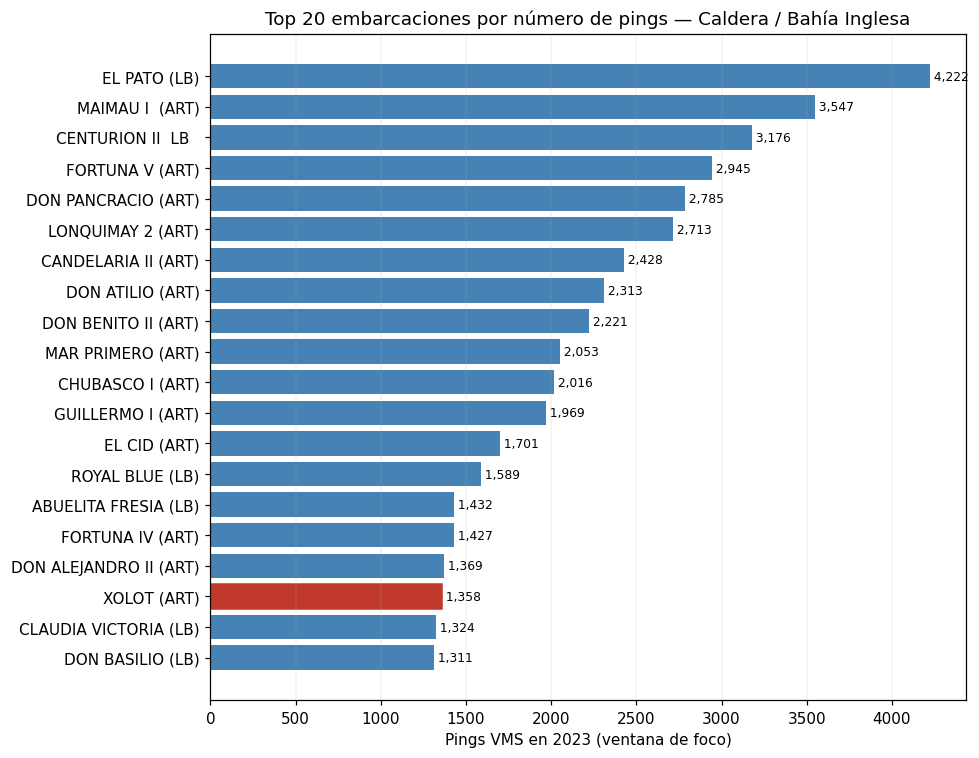

In [ ]:
TOP_N = 20
top = df["Name"].value_counts().head(TOP_N).iloc[::-1]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(top.index, top.values, color="steelblue")
ax.set_xlabel("Pings VMS en 2023 (ventana de foco)")
ax.set_title(f"Top {TOP_N} embarcaciones por número de pings — Caldera / Bahía Inglesa")
ax.grid(axis="x", linewidth=0.3, alpha=0.5)

# Anota XOLOT (ART) si entra en el top — sirve de referencia cruzada con el otro notebook.
for bar, name in zip(bars, top.index):
    if name == "XOLOT (ART)":
        bar.set_color("#c0392b")

for bar, val in zip(bars, top.values):
    ax.text(val, bar.get_y() + bar.get_height() / 2,
            f" {val:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Trayectorias semanales + idoneidad de hábitat + desembarques

El panel central del notebook. Para cada boletín semanal de [../data/landings/weekly_desembarques.csv](../data/landings/weekly_desembarques.csv) que cae en Febrero–Junio 2023 (≈ 22 semanas), se compone una sola figura con tres capas alineadas espacialmente sobre la ventana de Caldera / Bahía Inglesa:

1. **Idoneidad de hábitat de jurel** (cmap `YlGn`, α = 0.55) — `combined_suitability` promediada en la semana, sobre la grilla 1/24°. La capa baja le dice al ojo dónde *esperarías* ver flota artesanal en esa semana según el clima.
2. **Pings VMS** de toda la flota artesanal en esa semana, coloreados por velocidad (`viridis`). Encima del hábitat se lee directamente: ¿están los botes donde la idoneidad es alta? ¿O persiguen otra cosa?
3. **Caja de desembarques** de esa semana (`jurel_t`, `caballa_t`, etc., tomada directamente de la fila del boletín — sin agregación).

Cada panel es independiente, pero la escala de velocidad (`SPEED_VMAX`) y la escala de idoneidad (0–1) son compartidas, así que los colores son comparables entre semanas. La línea segmentada roja sigue marcando las 5 mn artesanales como referencia regulatoria.

In [ ]:
MESES_ES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
            "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

LANDINGS_PATH = "data/landings/weekly_desembarques.csv"
landings = pd.read_csv(LANDINGS_PATH)
landings["start_date"] = pd.to_datetime(landings["start_date"])
if "end_date" in landings.columns:
    landings["end_date"] = pd.to_datetime(landings["end_date"])
else:
    landings["end_date"] = landings["start_date"] + pd.Timedelta(days=7)

SPECIES = {
    "jurel_t":            "Jurel",
    "caballa_t":          "Caballa",
    "anchoveta_t":        "Anchoveta",
    "sardina_espanola_t": "Sardina esp.",
}

# Boletines de Feb–Jun 2023, en orden cronológico.
weekly = (
    landings[landings["start_date"].dt.month.between(2, 6)]
    .sort_values("start_date")
    .reset_index(drop=True)
)
print(f"Semanas a graficar: {len(weekly)}")

for _, row in weekly.iterrows():
    start = row["start_date"]
    end = row["end_date"]
    df_w = df_v[(df_v["Location date"] >= start) & (df_v["Location date"] < end)]
    suit = weekly_suitability(start, end)

    fig = plt.figure(figsize=(8, 11))
    if HAS_CARTOPY:
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.set_extent(
            [FOCUS_LON_MIN, FOCUS_LON_MAX, FOCUS_LAT_MIN, FOCUS_LAT_MAX],
            crs=ccrs.PlateCarree(),
        )
        ax.add_feature(cfeature.OCEAN,     facecolor="#eef5ff", zorder=0)
        habitat_kwargs = dict(transform=ccrs.PlateCarree())
        scatter_kwargs = dict(transform=ccrs.PlateCarree())
        # Tierra y costa se dibujan DESPUÉS del heatmap para que el verde no
        # invada los continentes; los pings van arriba de todo.
        ax.add_feature(cfeature.LAND,      facecolor="lightgray", zorder=3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.9, zorder=4)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
    else:
        ax = fig.add_subplot(1, 1, 1)
        ax.set_xlim(FOCUS_LON_MIN, FOCUS_LON_MAX)
        ax.set_ylim(FOCUS_LAT_MIN, FOCUS_LAT_MAX)
        ax.set_aspect("equal")
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        ax.grid(True, linewidth=0.3, alpha=0.5)
        habitat_kwargs = {}
        scatter_kwargs = {}

    # ----- Capa 1: idoneidad de hábitat -----
    pm = ax.pcolormesh(
        suit["longitude"], suit["latitude"], suit.values,
        cmap="YlGn", vmin=0.0, vmax=1.0,
        alpha=0.55, shading="nearest", zorder=1,
        **habitat_kwargs,
    )

    # ----- Capa 2: pings VMS -----
    sc = ax.scatter(
        df_w["Longitude"], df_w["Latitude"],
        c=df_w["Speed (kt)"], cmap="viridis",
        s=10, alpha=0.12, edgecolor="none",
        vmin=0, vmax=SPEED_VMAX,
        rasterized=True, zorder=5,
        **scatter_kwargs,
    )

    plot_offshore_5nm(ax, transform=habitat_kwargs.get("transform"))
    ax.legend(loc="lower right", fontsize=8, framealpha=0.85)

    # Dos colorbars: idoneidad a la izquierda, velocidad a la derecha.
    cbar_h = fig.colorbar(pm, ax=ax, fraction=0.045, pad=0.06, location="left")
    cbar_h.set_label("Idoneidad de hábitat (0–1)")
    cbar_h.solids.set_alpha(1.0)

    cbar_v = fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.06)
    cbar_v.set_label("Velocidad (kt)")
    cbar_v.solids.set_alpha(1.0)

    titulo_fecha = (
        f"{start.day} {MESES_ES[start.month - 1]} – "
        f"{(end - pd.Timedelta(days=1)).day} {MESES_ES[(end - pd.Timedelta(days=1)).month - 1]} 2023"
    )
    ax.set_title(
        f"Flota artesanal — semana {titulo_fecha}\n"
        f"({len(df_w):,} pings, {df_w['Name'].nunique()} embarcaciones)"
    )

    # Caja de desembarques con los datos de la fila (semanal, sin agregación).
    lineas = [f"Desembarques flota artesanal — {titulo_fecha}"]
    for col, label in SPECIES.items():
        if col in row.index:
            lineas.append(f"  {label:<13s} {int(row[col]):>6,d} t")
    ax.text(
        0.02, 0.98, "\n".join(lineas),
        transform=ax.transAxes,
        fontsize=9, family="monospace",
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.5",
                  facecolor="white", alpha=0.88, edgecolor="gray"),
    )

    plt.tight_layout()
    plt.show()

## 7. Notas

- Mismo lenguaje visual que [01_xolot_trajectory.ipynb](01_xolot_trajectory.ipynb): el color codifica velocidad instantánea, con `SPEED_VMAX` fijo a partir del percentil 98 de la flota dentro de la ventana de foco. Los caladeros aparecen como manchas oscuras (≲ 2 kt) densas; las rutas claras (≳ 5 kt) son navegación entre puerto y caladero.
- La ventana de foco es **Caldera / Bahía Inglesa** (lat -27.55 a -26.55, lon -71.4 a -70.8) — idéntica a la que comparten las secciones 2 y 4 de [01_xolot_trajectory.ipynb](01_xolot_trajectory.ipynb). El CSV consolidado trae bastante ruido de pings fuera de Atacama (boats con VMS reportando muy lejos), y el filtrado a la ventana de foco también los elimina como efecto colateral.
- El bbox completo de Atacama (lat -29 a -25, lon -72 a -70), definido en [processing/utils/cmems_common.py](../processing/utils/cmems_common.py), se conserva como referencia regional (`LAT_MIN..LON_MAX`) — coincide con la grilla unificada SST/CHL para cruces futuros.
- Con puntos pequeños y transparencia alta la densidad la construye el solapamiento, no el tamaño de marcador. El `rasterized=True` evita que matplotlib serialice millones de vectores cuando se guarda como PDF/SVG.
- La línea segmentada roja marca el **límite de las 5 millas marinas** (LGPA art. 47, zona reservada artesanal). Lo que cae al oeste de esa línea ya está fuera del régimen artesanal exclusivo.
- El ranking de la sección 5 mide **horas en el mar dentro de la ventana** (pings), no captura. Embarcaciones calado mucho tiempo en un punto suman pings sin desembarcar proporcionalmente.
- Los pings con `Speed (kt) == '-'` (velocidad faltante) quedan fuera de los mapas pero se contabilizan en la sección 1.
- La **capa de idoneidad de hábitat** (sección 3, aplicada en la sección 6) es literatura, no datos: las constantes `SST_PLATEAU`, `SST_TOLERANCE`, `CHL_HALF_SAT` y `CHL_SATURATION` viven al inicio del cell de hábitat y se recalibran sin tocar el resto del notebook. La forma de las curvas se puede inspeccionar en la salida de verificación de ese cell.
- **Limitación temporal del heatmap**: la SST y CHL diarias tienen días faltantes (nubes, gaps de retrieval). La media semanal los ignora vía `skipna=True`, pero semanas con cobertura muy escasa pueden mostrar celdas NaN — se ven transparentes sobre el océano de cartopy. Si todo un panel sale transparente, revisar si esa semana cayó dentro del rango temporal de los productos descargados.